In [22]:
# Подключение библиотек для работы с нейронными сетями
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F
# Подключение библиотеки для работы с массивами
import numpy as np
# Подключение библиотек для отрисовки изображений
import matplotlib.pyplot as plt
# Подключение модуля для работы с файлами
import os
# Подключение библиотеки для загрузки изображений
from PIL import Image
# Вывод изображения в ноутбуке, а не в консоли или файле

In [6]:
# Загрузка датасета из облака
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_light.zip', None, quiet=True)

'hw_light.zip'

In [7]:
# Распаковываем архив hw_light.zip в папку hw_light
import zipfile
with zipfile.ZipFile('hw_light.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [8]:

# Путь к директории с базой
base_dir = 'hw_light'

# Создание пустого списка для загрузки изображений обучающей выборки
x_train = []
# Создание списка для меток классов
y_train = []
# Задание высоты и ширины загружаемых изображений
img_height = 20
img_width = 20

# Перебор папок в директории базы
for patch in os.listdir(base_dir):
    patch_path = os.path.join(base_dir, patch)
    if os.path.isdir(patch_path):
        # Перебор файлов в папках
        for img in os.listdir(patch_path):
            # Загрузка изображения в градациях серого и изменение размера
            img_path = os.path.join(patch_path, img)
            image = Image.open(img_path).convert('L')
            image = image.resize((img_width, img_height))
            img_array = np.array(image)

            # Добавление в список изображений текущей картинки
            x_train.append(img_array)

            # Добавление в массив меток, соответствующих классам
            if patch == '0':
                y_train.append(0)
            elif patch == '3':
                y_train.append(1)
            else:
                y_train.append(2)

# Преобразование в numpy-массив загруженных изображений и меток классов
x_train = np.array(x_train)
y_train = np.array(y_train)

# Вывод размерностей
print('Размер массива x_train', x_train.shape)
print('Размер массива y_train', y_train.shape)

Размер массива x_train (302, 20, 20)
Размер массива y_train (302,)


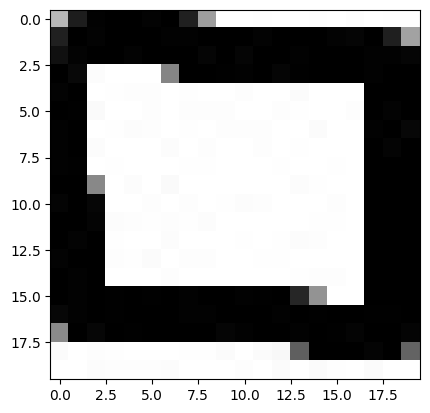

2


In [21]:
# Проверка
n = 50
plt.imshow(x_train[n], cmap='gray')
plt.show()
print(y_train[n])

In [20]:
# Изменение формы входных картинок с 20х20 на 400
x_train_n = x_train.reshape(x_train.shape[0], -1)
# Проверка результата
print(f'Форма обучающих данных: {x_train.shape} -> {x_train_n.shape}')
# Преобразование x_train в тип float32 (числа с плавающей точкой) и нормализация
x_train_n = x_train_n.astype('float32') / 255.

Форма обучающих данных: (302, 20, 20) -> (302, 400)


In [18]:

CLASS_COUNT = 3
# Преобразование в тензоры PyTorch
x_train_tensor = torch.FloatTensor(x_train_n)
y_train_tensor = torch.LongTensor(y_train)
y_train_n = F.one_hot(y_train_tensor, num_classes=CLASS_COUNT).float()
print(y_train_n.shape)
print(y_train_n[0])
print(y_train_n[126])

torch.Size([302, 3])
tensor([0., 0., 1.])
tensor([0., 1., 0.])


In [19]:
# Создание Dataset и DataLoader
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)

In [17]:
# Гиперпараметры
neurons_list = [10, 100, 5000]
activations = ['relu', 'linear']
batch_sizes = [10, 100, 1000]

results = []
class SimpleNN(nn.Module):
    def __init__(self, neurons=10, activation='relu'):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(400, neurons)
        self.fc2 = nn.Linear(neurons, neurons)
        self.fc3 = nn.Linear(neurons, CLASS_COUNT)

        if activation == 'relu':
            self.activation = nn.ReLU()
        else:
            self.activation = nn.Identity()

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)
        return x

In [14]:
# Создам функцию обучения, чтобы возвращать accuracy
def train_model(model, train_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())

    model.train()

    for epoch in range(epochs):
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    return accuracy

In [15]:
# 🔁 Перебор всех комбинаций
for neurons in neurons_list:
    for activation in activations:
        for batch_size in batch_sizes:

            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

            model = SimpleNN(neurons=neurons, activation=activation)

            acc = train_model(model, train_loader, epochs=10)

            print(f"neurons={neurons}, activation={activation}, batch={batch_size} -> acc={acc:.4f}")

            results.append({
                'neurons': neurons,
                'activation': activation,
                'batch_size': batch_size,
                'accuracy': acc
            })


neurons=10, activation=relu, batch=10 -> acc=0.7781
neurons=10, activation=relu, batch=100 -> acc=0.5397
neurons=10, activation=relu, batch=1000 -> acc=0.3311
neurons=10, activation=linear, batch=10 -> acc=0.8046
neurons=10, activation=linear, batch=100 -> acc=0.4834
neurons=10, activation=linear, batch=1000 -> acc=0.5993
neurons=100, activation=relu, batch=10 -> acc=0.9106
neurons=100, activation=relu, batch=100 -> acc=0.6325
neurons=100, activation=relu, batch=1000 -> acc=0.7517
neurons=100, activation=linear, batch=10 -> acc=0.8212
neurons=100, activation=linear, batch=100 -> acc=0.6391
neurons=100, activation=linear, batch=1000 -> acc=0.7318
neurons=5000, activation=relu, batch=10 -> acc=0.9338
neurons=5000, activation=relu, batch=100 -> acc=0.8709
neurons=5000, activation=relu, batch=1000 -> acc=0.6093
neurons=5000, activation=linear, batch=10 -> acc=0.6854
neurons=5000, activation=linear, batch=100 -> acc=0.6689
neurons=5000, activation=linear, batch=1000 -> acc=0.5099


In [16]:
import pandas as pd
df = pd.DataFrame(results)
print("\nСравнительная таблица:")
print(df)


Сравнительная таблица:
    neurons activation  batch_size  accuracy
0        10       relu          10  0.778146
1        10       relu         100  0.539735
2        10       relu        1000  0.331126
3        10     linear          10  0.804636
4        10     linear         100  0.483444
5        10     linear        1000  0.599338
6       100       relu          10  0.910596
7       100       relu         100  0.632450
8       100       relu        1000  0.751656
9       100     linear          10  0.821192
10      100     linear         100  0.639073
11      100     linear        1000  0.731788
12     5000       relu          10  0.933775
13     5000       relu         100  0.870861
14     5000       relu        1000  0.609272
15     5000     linear          10  0.685430
16     5000     linear         100  0.668874
17     5000     linear        1000  0.509934
